<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h1 style="color: #1e3a8a; border-bottom: 3px solid #1e3a8a; padding-bottom: 8px; margin-bottom: 4px;">PPE Compliance Detection Pipeline</h1>

<h2 style="color: #1e40af; font-weight: 600; margin-top: 6px; margin-bottom: 20px;">Cross-Dataset Evaluation on Construction-Site Imagery</h2>

<table style="border-collapse: collapse; font-size: 14px; margin-bottom: 20px;">
  <tr><td style="padding: 4px 16px 4px 0; color: #475569; font-weight: 600;">Submitters</td><td style="padding: 4px 0;">Raz Albaz (ID 315837658) &middot; Mika Melamed (ID 207488453)</td></tr>
  <tr><td style="padding: 4px 16px 4px 0; color: #475569; font-weight: 600;">Course</td><td style="padding: 4px 0;">Deep Learning Workshop &middot; Dr. Anat Goldstein &middot; M.Sc. Knowledge &amp; Data Engineering, Ariel University</td></tr>
  <tr><td style="padding: 4px 16px 4px 0; color: #475569; font-weight: 600;">Semester</td><td style="padding: 4px 0;">Spring 2026</td></tr>
  <tr><td style="padding: 4px 16px 4px 0; color: #475569; font-weight: 600;">Repository</td><td style="padding: 4px 0;"><code>github.com/Razelbaz1/ppe-compliance-detection</code></td></tr>
</table>

<h3 style="color: #1e40af; margin-top: 18px;">Abstract</h3>

<div style="background: #fef3c7; border: 1px solid #fbbf24; padding: 10px 14px; border-radius: 4px; color: #78350f;">
<em><strong>Placeholder.</strong> The abstract will be written at the end of the project, after all experiments are complete. Writing it last ensures it accurately reflects the results that were actually achieved rather than the goals that were planned.</em>
</div>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">1. Introduction</h2>

<h3 style="color: #1e40af; margin-top: 18px;">1.1 The Problem</h3>
<p style="text-align: justify;">
Non-compliance with safety procedures on construction sites endangers human lives.
This project trains a deep learning model on images of construction-site workers to <strong>distinguish, per worker, who is complying with safety procedures and who is not</strong>.
The safety procedures considered in scope are <strong>wearing a hard-hat (helmet)</strong> and <strong>wearing a high-visibility vest</strong>.
</p>

<h3 style="color: #1e40af; margin-top: 18px;">1.2 Project Goal</h3>
<p style="text-align: justify;">
Build a <strong>two-stage pipeline</strong> that decomposes the problem into two well-understood sub-tasks, each solved by an appropriate model:
</p>
<ol>
  <li><strong>Stage 1 &mdash; Person Detection:</strong> locate each worker in the image as a bounding box, using a YOLOv8 detector fine-tuned on construction-site data.</li>
  <li><strong>Stage 2 &mdash; PPE Classification:</strong> crop each detected worker and pass it through a CNN (with transfer learning) that outputs two independent multi-label predictions &mdash; "is wearing helmet?" and "is wearing vest?".</li>
  <li><strong>Stage 3 &mdash; Compliance Logic:</strong> a simple rule on top of Stage 2 outputs &mdash; <code>compliant = helmet &and; vest</code>. Any other combination is flagged as non-compliance with the missing item itemised.</li>
</ol>
<p style="text-align: justify;">
This two-stage decomposition is deliberate: each stage solves a classical, well-bounded task (detection vs. classification) for which strong pretrained models are publicly available &mdash; enabling effective transfer learning even with modestly-sized data.
</p>

<h3 style="color: #1e40af; margin-top: 18px;">1.3 Evaluation Metrics</h3>

<p>To assess the quality of the model at each stage of the project, we will use the following metrics:</p>

<div style="background: #fef3c7; border: 1px solid #fbbf24; padding: 10px 14px; border-radius: 4px; color: #78350f;">
<em><strong>Placeholder.</strong> The list of metrics will be filled in as each stage is evaluated, based on what is actually appropriate once we see the data and the trained models.</em>
</div>

<h3 style="color: #1e40af; margin-top: 18px;">1.4 Out of Scope</h3>
<ul>
  <li>Detection of additional PPE items (gloves, goggles, safety boots) &mdash; the datasets support them, but we focus on hard-hat and vest, which are the most safety-critical and the best-represented classes in the data.</li>
  <li>Worker tracking over time (<em>multi-object tracking</em>) &mdash; each frame is treated independently; no video-sequence reasoning.</li>
  <li>Worker identification &mdash; workers are treated as anonymous objects.</li>
  <li>Production deployment &mdash; real-time camera streaming, model optimization for edge devices, MLOps. Outside the scope of an academic course project.</li>
</ul>

<h3 style="color: #1e40af; margin-top: 18px;">1.5 Notebook Structure</h3>
<p>The notebook is organised by chapters. Each chapter contains a brief theoretical explanation, the code that implements it, and a summary of what we learned from it:</p>
<ol>
  <li>Introduction and project goals (current chapter)</li>
  <li>Theoretical background &mdash; Object Detection, Transfer Learning, IoU, evaluation metrics</li>
  <li>Environment setup and imports</li>
  <li><strong>Data split &mdash; Cross-Dataset Strategy</strong></li>
  <li>Exploratory Data Analysis (EDA)</li>
  <li>Deduplication and leakage check (pHash)</li>
  <li>Data preparation for Stage 1</li>
  <li><strong>Stage 1</strong> &mdash; YOLOv8 training for person detection</li>
  <li>Stage 1 evaluation</li>
  <li>Worker-crop dataset construction for Stage 2</li>
  <li><strong>Stage 2</strong> &mdash; CNN multi-label classifier training</li>
  <li>Stage 2 evaluation</li>
  <li><strong>Stage 3</strong> &mdash; Compliance Logic</li>
  <li>End-to-End evaluation on full images</li>
  <li>Discussion, limitations, and future work</li>
  <li>Summary and conclusions</li>
  <li>References</li>
</ol>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.65;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">2. Theoretical Background</h2>

<p style="text-align: justify;">
Before we start coding the pipeline, this chapter reviews the concepts that will appear in the code in later chapters.
Each concept is presented in a <strong>three-layer format</strong>: <em>intuition</em> &middot;
<em>mathematical formulation</em> &middot; <em>why it matters in this project</em>.
</p>

<p>The chapter is split into two worlds that correspond to the two stages of the pipeline:</p>
<ul>
  <li><strong>2.1&ndash;2.5 &mdash; The detection world:</strong> how objects are located inside an image &mdash;
      everything needed to understand Stage 1.</li>
  <li><strong>2.6&ndash;2.9 &mdash; The classification world:</strong> Transfer Learning, multi-label classification,
      the loss function, and augmentation &mdash; everything needed to understand Stage 2.</li>
</ul>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.65;">

<h3 style="color: #1e40af; margin-top: 18px;">2.1 Object Detection &mdash; how it differs from regular classification</h3>
<p><strong style="color:#1e40af;">Intuition.</strong> <strong>Classification</strong> says &quot;this image contains a cat&quot; &mdash; one label for the whole image. <strong>Detection</strong> says &quot;<em>here</em> in the image is a cat, <em>here</em> is a dog, and here are other objects&quot; &mdash; every object gets both a class and a position.</p>
<p><strong style="color:#1e40af;">Formally.</strong> Classification model: <code>f(image) &rarr; vector of K probabilities</code> (one per class).<br>Detection model: <code>f(image) &rarr; list of {bbox, class, confidence}</code> &mdash; one entry per detected object. The number of outputs is <em>not fixed</em>: one image may contain 0 objects or 50.</p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> A construction-site image can contain one worker or twenty. Classification alone is not enough &mdash; we need a detector that gives us a separate bbox for each worker, so the PPE classifier can be applied to each worker independently.</p>

<h3 style="color: #1e40af; margin-top: 18px;">2.2 Bounding Box (bbox) &mdash; how an object is represented</h3>
<p><strong style="color:#1e40af;">Intuition.</strong> A tight rectangle that wraps an object in the image. The detector has two parallel jobs: <em>where</em> the object is (bbox) and <em>what</em> it is (class).</p>
<p><strong style="color:#1e40af;">Formally.</strong> Represented by 4 numbers. Three common formats appear in code:<table style='border-collapse:collapse;font-size:13px;margin-top:6px;'><tr><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Format</th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Fields</th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Where it's used</th></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;"><code>XYXY</code></td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">(x_min, y_min, x_max, y_max)</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">Pascal VOC, OpenCV</td></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;"><code>XYWH</code></td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">(x, y, width, height)</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">COCO</td></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;"><code>YOLO</code></td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">(cx, cy, w, h) &mdash; normalized to [0, 1]</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;"><strong>Our format</strong></td></tr></table></p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> Each <code>.txt</code> file in <code>datasets/.../labels/</code> contains one bbox per line in YOLO format. Example from the actual data:<pre style='background:#f8fafc;padding:8px;border-radius:4px;font-size:13px;'>0 0.523 0.412 0.180 0.350</pre><strong>Reading it:</strong> class 0 (helmet), bbox center at (52.3%, 41.2%) of the image, width 18% and height 35% of the image dimensions. This is what YOLO reads at training time and what it predicts at inference time.</p>

<h3 style="color: #1e40af; margin-top: 18px;">2.3 IoU &mdash; Intersection over Union</h3>
<p><strong style="color:#1e40af;">Intuition.</strong> A metric that captures &quot;how much do two rectangles overlap&quot;. A value of 1 means they overlap perfectly; 0 means they do not touch at all.</p>
<p><strong style="color:#1e40af;">Formally.</strong> <code>IoU(A, B) = |A &cap; B| / |A &cup; B|</code><br><strong>Numeric example:</strong> predicted bbox = (10, 10, 50, 50), ground-truth bbox = (20, 20, 60, 60).<br>&bull; Intersection area = 30 &times; 30 = <strong>900</strong><br>&bull; Union area = 1600 + 1600 &minus; 900 = <strong>2300</strong><br>&bull; IoU = 900 / 2300 &asymp; <strong>0.39</strong> (a partial overlap).</p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> IoU shows up in three places in our project:<table style='border-collapse:collapse;font-size:13px;margin-top:6px;'><tr><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Where</th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Role</th></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">During YOLO training</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">YOLO computes IoU between its prediction and ground truth as part of the loss</td></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">During evaluation</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">A prediction counts as &quot;correct&quot; if IoU with ground truth &ge; 0.5 (the threshold for mAP@0.5)</td></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">In our <code>build_crop_dataset.py</code></td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">We compute IoU <em>by hand</em> to decide whether a person crop is labelled as &quot;wearing a helmet&quot; &mdash; by checking whether a helmet bbox overlaps that person's bbox</td></tr></table></p>

<h3 style="color: #1e40af; margin-top: 18px;">2.4 YOLO &mdash; the detector architecture we use</h3>
<p><strong style="color:#1e40af;">Intuition.</strong> <strong>Y</strong>ou <strong>O</strong>nly <strong>L</strong>ook <strong>O</strong>nce. Unlike R-CNN, which looks at the image twice (first to find candidate regions, then to classify them), YOLO performs the entire detection in a <em>single forward pass</em> &mdash; which makes it very fast.</p>
<p><strong style="color:#1e40af;">Formally.</strong> The image passes through a CNN that produces feature maps at several resolutions (FPN). Each grid cell is &quot;responsible&quot; for objects whose center falls inside it, and predicts:<ul><li>B bounding boxes (position + size)</li><li>A probability distribution over K classes</li><li>A confidence score that captures &quot;how sure am I there is an object here&quot;</li></ul><strong>YOLOv8 is anchor-free:</strong> unlike earlier YOLO versions, it does not rely on pre-defined &quot;anchor boxes&quot; &mdash; it predicts the bbox directly.</p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> We adopt the YOLO architecture because our data is well-suited to it: a single-class detection task (person) with a moderate number of training images, where pretrained YOLO weights on COCO provide a strong starting point.</p>

<h3 style="color: #1e40af; margin-top: 18px;">2.5 mAP, Precision, Recall &mdash; how detectors are measured</h3>
<p><strong style="color:#1e40af;">Intuition.</strong> <strong>Precision</strong> = of all the detections I made, how many were correct? &quot;How often do I lie?&quot;<br><strong>Recall</strong> = of all the objects that were truly in the image, how many did I find? &quot;How often am I lazy?&quot;<br><strong>mAP</strong> = a single score that combines both.</p>
<p><strong style="color:#1e40af;">Formally.</strong> Every prediction is sorted into one of four categories based on IoU against ground truth:<ul><li><strong>TP</strong> (True Positive): IoU &ge; 0.5 AND the class is correct</li><li><strong>FP</strong> (False Positive): a detection that does not match any real object</li><li><strong>FN</strong> (False Negative): a real object that was not detected</li></ul><code>Precision = TP / (TP + FP)</code><br><code>Recall = TP / (TP + FN)</code><br><code>AP = area under the Precision-Recall curve</code><br><code>mAP = mean AP averaged over all classes</code></p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> YOLO reports <strong>two</strong> mAP variants:<ul><li><code>mAP@0.5</code> &mdash; IoU threshold of 0.5 (lenient).</li><li><code>mAP@0.5:0.95</code> &mdash; average across 10 thresholds (0.5, 0.55, &hellip;, 0.95). Much stricter.</li></ul>In our project: <em>low Precision</em> means the model often shouts &quot;I see a worker!&quot; when none is there; <em>low Recall</em> means real workers are missed. For PPE compliance, <strong>Recall is the more important of the two</strong> &mdash; missing a worker means missing a potential non-compliance event.</p>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.65;">

<h3 style="color: #1e40af; margin-top: 18px;">2.6 Transfer Learning &mdash; building on pretrained models</h3>

<p><strong style="color:#1e40af;">Intuition.</strong>
Rather than training a CNN from scratch on our modest dataset (~12K crops),
we start from a model already trained on a massive dataset (ImageNet &mdash; 1.4M images, 1000 classes)
and leverage the representations it has already learned &mdash; edges, textures, shapes &mdash; which transfer
well to our domain.
</p>

<p><strong style="color:#1e40af;">Formally.</strong>
Two usage modes:
<ul>
  <li><strong>Feature Extraction:</strong> freeze the backbone (<code>conv_base.trainable = False</code>) and train only a fresh classifier head (a new Dense layer).</li>
  <li><strong>Fine-Tuning:</strong> unfreeze the top layers of the backbone and continue training with a <em>very low</em> learning rate (1e-5) so the pretrained weights are not destroyed.</li>
</ul>
</p>

<p><strong style="color:#1e40af;">Why we use it here.</strong>
Transfer Learning is the natural choice for this project because, as demonstrated in the course lecture on Transfer Learning (Unit 8 &mdash; Cats vs Dogs), training from scratch on a small dataset reached only ~66% accuracy, while feature extraction reached ~83% and fine-tuning reached ~97% &mdash; with only 2,000 training images.
With ~12K crops in our Stage 2 dataset, the same approach is the only practical way to reach competitive accuracy: training the CNN from scratch would leave a large fraction of the model's potential on the table.
</p>

<h3 style="color: #1e40af; margin-top: 18px;">2.7 Multi-Label Classification &mdash; multiple labels per example</h3>
<p><strong style="color:#1e40af;">Intuition.</strong> <strong>Multi-class</strong> asks &quot;what is this?&quot; &mdash; <em>one</em> of K choices (cat <em>or</em> dog <em>or</em> bird).<br><strong>Multi-label</strong> asks &quot;which attributes does it have?&quot; &mdash; <em>any subset</em> of K attributes (wearing helmet <em>and</em> wearing vest).</p>
<p><strong style="color:#1e40af;">Formally.</strong> <strong>The critical architectural difference:</strong><table style='border-collapse:collapse;font-size:13.5px;margin-top:6px;'><tr><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;"></th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Output layer</th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Activation</th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Loss</th><th style="padding: 4px 10px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Sum of probabilities</th></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">Multi-class</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">Dense(K)</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">softmax</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">categorical_crossentropy</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">= 1</td></tr><tr><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">Multi-label</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">Dense(K)</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">sigmoid</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">binary_crossentropy</td><td style="padding: 4px 10px; border: 1px solid #cbd5e1;">not necessarily = 1</td></tr></table><p>In our project: K=2 (helmet, vest), two independent sigmoid neurons. Example output: <code>[0.87, 0.12]</code> = &quot;87% confidence wearing a helmet, 12% confidence wearing a vest&quot;.</p></p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> If we mistakenly used softmax with 2 heads, we would force helmet and vest to <em>compete</em> &mdash; raising the helmet probability would lower the vest probability. This does not match reality: a worker can wear both. Independent sigmoids allow independent decisions.</p>

<h3 style="color: #1e40af; margin-top: 18px;">2.8 BCE Loss &mdash; Binary Cross-Entropy</h3>

<div style="background: #f0fdf4; border-left: 3px solid #16a34a; padding: 6px 12px; margin: 8px 0; border-radius: 4px 0 0 4px; font-size: 13.5px; color: #14532d;">
<strong>&#9989; Covered in the course:</strong> Unit 4 (NN Optimization) and Unit 6 (Keras &mdash; IMDB classification).
</div>

<p><strong style="color:#1e40af;">Intuition.</strong> A metric that says &quot;how far is my prediction from the ground truth&quot; for a binary problem. The more confidently wrong the model is, the higher the loss; the more correct it is, the closer the loss is to 0.</p>
<p><strong style="color:#1e40af;">Formally.</strong> For one example and one label:<br><code>BCE(y, &ycirc;) = &minus;[y &middot; log(&ycirc;) + (1&minus;y) &middot; log(1&minus;&ycirc;)]</code><br>where <code>y &isin; {0, 1}</code> (the ground truth) and <code>&ycirc; &isin; [0, 1]</code> (sigmoid output).<br><br><strong>For the multi-label case:</strong> BCE is summed over all K labels; in Keras, <code>binary_crossentropy</code> automatically averages.<br><br><strong>Numeric example:</strong> y=1, &ycirc;=0.9 &rArr; BCE = &minus;log(0.9) &asymp; 0.105 (low, good).<br>y=1, &ycirc;=0.1 &rArr; BCE = &minus;log(0.1) &asymp; 2.30 (high &mdash; the model is penalized for confident wrongness).</p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> BCE is the standard loss for Stage 2 in our project &mdash; <code>model.compile(loss='binary_crossentropy', metrics=['accuracy', 'AUC'])</code>. What makes it appropriate: it is <em>asymmetric</em> &mdash; it punishes very-wrong predictions much more than slightly-wrong ones. This pushes the model to be honest rather than declare &quot;100% sure&quot; without justification.</p>

<h3 style="color: #1e40af; margin-top: 18px;">2.9 Data Augmentation &mdash; artificially expanding the dataset</h3>

<div style="background: #f0fdf4; border-left: 3px solid #16a34a; padding: 6px 12px; margin: 8px 0; border-radius: 4px 0 0 4px; font-size: 13.5px; color: #14532d;">
<strong>&#9989; Covered in the course:</strong> Unit 8 (Cats vs Dogs) &mdash; demonstrated to push back overfitting from epoch 5 to epoch 30+.
</div>

<p><strong style="color:#1e40af;">Intuition.</strong> &quot;Invent new images&quot; from the existing ones by applying random transformations (flip, rotation, brightness change, crop). Each epoch the network sees slightly different versions of the same image &mdash; as if the dataset were several times larger.</p>
<p><strong style="color:#1e40af;">Formally.</strong> <strong>Common techniques we will use:</strong><ul><li><strong>Geometric:</strong> <code>RandomFlip('horizontal')</code> (important!), <code>RandomRotation(0.05)</code>, <code>RandomZoom(0.1)</code></li><li><strong>Photometric:</strong> <code>RandomBrightness(0.2)</code>, <code>RandomContrast(0.2)</code> &mdash; essential because lighting varies a lot across construction sites</li></ul><strong>What we will <em>not</em> use:</strong> vertical flip &mdash; an upside-down worker is not a realistic scenario and would teach the network that a back = a head.</p>
<p><strong style="color:#1e40af;">Why it matters here.</strong> In Stage 1, YOLO performs its own built-in augmentation (mosaic, mixup, copy-paste) &mdash; we don't need to do anything. In Stage 2 (CNN), we will build an augmentation pipeline in Keras as preprocessing layers. Without augmentation, with only ~12K crops, there is a serious risk of overfitting after 5&ndash;10 epochs.</p>

<div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 6px; padding: 10px 14px; margin-top: 20px; color: #1e3a8a;">
  <strong>&#9989; Chapter summary.</strong> We are now equipped with the concepts that will appear in every later chapter &mdash;
  Detection (bbox, IoU, mAP, YOLO) and Classification (Transfer Learning, multi-label, BCE, augmentation).
</div>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">3. Environment Setup</h2>

<p style="text-align: justify;">
The two code cells below prepare the runtime so the rest of the notebook can run:
</p>

<ul>
  <li><strong>3.1 &mdash; Environment detection &amp; paths.</strong> Detects whether the notebook is running locally, on a remote workstation (SSH), or on Google Colab, and resolves <code>REPO_ROOT</code> and <code>DATA_ROOT</code> accordingly.</li>
  <li><strong>3.2 &mdash; Imports, seeds, and GPU check.</strong> Imports the required libraries, seeds <code>random</code> / <code>numpy</code> / <code>tensorflow</code> / <code>torch</code> with <code>SEED = 42</code>, and reports which GPU (if any) is available.</li>
</ul>

<p style="text-align: justify;">
Setup instructions &mdash; installation, dataset download, runtime auto-detection, the laptop-to-workstation workflow, and reproducibility caveats &mdash; live in the <strong><a href="../README.md#5-runtime-environments--workflow">Runtime Environments &amp; Workflow</a></strong> section of the README, so this chapter stays focused on the notebook itself.
</p>

</div>

In [1]:
# =============================================================================
# Chapter 3.1 - Environment detection and path resolution
# =============================================================================
import os
import sys
import platform
from pathlib import Path

# --- 1. Detect runtime environment -------------------------------------------
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

IS_SSH = bool(os.environ.get("SSH_CONNECTION") or os.environ.get("SSH_CLIENT"))
OS_NAME = platform.system()  # 'Windows', 'Linux', 'Darwin'

def _env_label() -> str:
    if IS_COLAB:
        return "Google Colab"
    if IS_SSH:
        return f"Linux SSH ({platform.node()})"
    return f"{OS_NAME} (Local)"

print(f"Environment   : {_env_label()}")

# --- 2. Resolve REPO_ROOT and DATA_ROOT --------------------------------------
if IS_COLAB:
    # Mount Drive (idempotent). Fallback to local-style search if it fails
    # (e.g. Colab Local Runtime where Drive is not exposed).
    try:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
    except Exception as e:
        print(f"  WARNING: Drive mount failed ({e}). Treating as local runtime.")
        IS_COLAB = False

if IS_COLAB:
    # Clone the project repo into /content/ if not present
    REPO_ROOT = Path("/content/ppe-compliance-detection")
    if not REPO_ROOT.exists():
        os.system(
            "git clone -q https://github.com/Razelbaz1/ppe-compliance-detection.git "
            f"{REPO_ROOT}"
        )

    DATA_ROOT_DEFAULT = Path("/content/drive/MyDrive/Deep_Learning_course/datasets")
    DATA_ROOT = Path(os.environ.get("PPE_DATA_ROOT", DATA_ROOT_DEFAULT))
else:
    # When launched from the notebooks/ folder, REPO_ROOT is one level up
    nb_dir = Path.cwd().resolve()
    REPO_ROOT = nb_dir.parent if nb_dir.name == "notebooks" else nb_dir

    # Search candidates in priority order
    env_override = os.environ.get("PPE_DATA_ROOT")
    home = Path.home()

    candidates: list = [
        Path(env_override) if env_override else None,
        REPO_ROOT.parent / "datasets",
        REPO_ROOT / "datasets",
        home / "datasets",
        home / "ppe-data" / "datasets",
    ]

    # Linux / SSH-typical shared locations
    if OS_NAME == "Linux":
        candidates += [
            Path("/data/Deep_Learning_course/datasets"),
            Path("/mnt/data/Deep_Learning_course/datasets"),
        ]

    # Windows-specific locations
    if OS_NAME == "Windows":
        candidates += [
            Path("G:/My Drive/Deep_Learning_course/datasets"),
            *list(home.glob("OneDrive*/Desktop/**/Deep_Learning_course/datasets")),
        ]

    candidates = [c for c in candidates if c is not None]

    DATA_ROOT = next(
        (c for c in candidates if (c / "construction-ppe").exists()),
        None,
    )
    if DATA_ROOT is None:
        hint = (
            "$env:PPE_DATA_ROOT = 'C:\\path\\to\\datasets'  # PowerShell"
            if OS_NAME == "Windows"
            else "export PPE_DATA_ROOT=$HOME/path/to/datasets       # bash"
        )
        raise FileNotFoundError(
            "Could not locate the datasets folder.\n"
            "Set PPE_DATA_ROOT to point at the folder containing "
            "'construction-ppe/' and 'kaggle-css/'. Example:\n"
            f"  {hint}"
        )

# --- 3. Derived paths --------------------------------------------------------
ULTRALYTICS_DIR = DATA_ROOT / "construction-ppe"
KAGGLE_DIR      = DATA_ROOT / "kaggle-css"
RESULTS_DIR     = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# --- 4. Make src/ importable from the notebook -------------------------------
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --- 5. Summary --------------------------------------------------------------
def _ok(p: Path) -> str:
    return "OK " if p.exists() else "MISSING"

print(f"REPO_ROOT     : {REPO_ROOT}")
print(f"DATA_ROOT     : {DATA_ROOT}")
print(f"  Ultralytics : {_ok(ULTRALYTICS_DIR)}  -> {ULTRALYTICS_DIR}")
print(f"  Kaggle CSS  : {_ok(KAGGLE_DIR)}  -> {KAGGLE_DIR}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")


Environment   : Windows (Local)
REPO_ROOT     : C:\Users\razel\github\ppe-compliance-detection
DATA_ROOT     : C:\Users\razel\OneDrive - Ariel University\Desktop\Ariel\M.Sc\semester2\Deep_Learning_course\datasets
  Ultralytics : OK   -> C:\Users\razel\OneDrive - Ariel University\Desktop\Ariel\M.Sc\semester2\Deep_Learning_course\datasets\construction-ppe
  Kaggle CSS  : OK   -> C:\Users\razel\OneDrive - Ariel University\Desktop\Ariel\M.Sc\semester2\Deep_Learning_course\datasets\kaggle-css
RESULTS_DIR   : C:\Users\razel\github\ppe-compliance-detection\results


In [2]:
# =============================================================================
# Chapter 3.2 - Imports, seeding, and GPU detection
# =============================================================================
import os
import random
import warnings

# Silence TF/Keras log noise BEFORE importing tensorflow
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

# --- Lightweight imports ------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. Seeding (must come before any DL framework use) ----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- 2. PyTorch — required from Chapter 7 (YOLO) ------------------------------
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- 3. TensorFlow — required from Chapter 10 (Stage 2 classifier) ------------
# Wrapped in try/except so the notebook still runs through EDA chapters even
# before TF is installed.
try:
    import tensorflow as tf
    tf.keras.utils.set_random_seed(SEED)
    HAS_TF = True
except ImportError:
    tf = None
    HAS_TF = False

# --- 4. Library versions -----------------------------------------------------
print("Library versions")
print(f"  numpy        {np.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  matplotlib   {plt.matplotlib.__version__}")
print(f"  torch        {torch.__version__}")
print(f"  tensorflow   {tf.__version__ if HAS_TF else 'NOT INSTALLED (required from Chapter 10)'}")
print()

# --- 5. GPU detection --------------------------------------------------------
print(f"PyTorch CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  - Device : {torch.cuda.get_device_name(0)}")
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  - Memory : {total_gb:.1f} GB")
else:
    print("  - CPU only. YOLO training will be slow. Recommended:")
    print("      * Google Colab (free T4 GPU)")
    print("      * Remote machine via SSH with NVIDIA GPU")

if HAS_TF:
    tf_gpus = tf.config.list_physical_devices("GPU")
    print(f"TensorFlow GPUs detected : {len(tf_gpus)}")
    for g in tf_gpus:
        print(f"  - {g.name}")
else:
    print()
    print("  NOTE: TensorFlow is not installed yet. The notebook will run")
    print("  through chapters 4-9 without it; install before Chapter 10:")
    print("      pip install tensorflow>=2.15.0")

print(f"\nRandom seed set to {SEED}.")


Library versions
  numpy        2.3.4
  pandas       2.3.3
  matplotlib   3.10.7
  torch        2.11.0+cpu
  tensorflow   NOT INSTALLED (required from Chapter 10)

PyTorch CUDA available  : False
  - CPU only. YOLO training will be slow. Recommended:
      * Google Colab (free T4 GPU)
      * Remote machine via SSH with NVIDIA GPU

  NOTE: TensorFlow is not installed yet. The notebook will run
  through chapters 4-9 without it; install before Chapter 10:
      pip install tensorflow>=2.15.0

Random seed set to 42.


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.65;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">4. Data Split &mdash; Cross-Dataset Strategy</h2>

<h3 style="color: #1e40af; margin-top: 18px;">4.1 The approach: Cross-Dataset Evaluation</h3>

<p style="text-align: justify;">
Our two datasets &mdash; Ultralytics Construction-PPE and Kaggle CSS &mdash; differ noticeably from each other: different sites, different photography style, and in particular very different compliance distributions (Ultralytics ~61% compliant, Kaggle ~20% compliant).
Rather than merging them into a standard train/val/test split (the common, less challenging approach), we adopt an academic approach called <strong>Cross-Dataset Evaluation</strong> &mdash; the model trains on one dataset entirely and is then evaluated on a different dataset that it has never seen during training.
</p>

<p>
The <strong>project narrative</strong>: <em>"the model succeeds in both worlds"</em> &mdash; both on the domain it has learned (in-domain) and on a completely new domain (out-of-domain).
</p>

<h3 style="color: #1e40af; margin-top: 18px;">4.2 The four splits</h3>

<table style="border-collapse: collapse; font-size: 13.5px; margin-top: 6px;">
  <thead><tr>
    <th style="padding: 6px 12px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Split</th>
    <th style="padding: 6px 12px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Source</th>
    <th style="padding: 6px 12px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Size</th>
    <th style="padding: 6px 12px; border: 1px solid #cbd5e1; background: #f1f5f9; text-align: left;">Role</th>
  </tr></thead>
  <tbody>
    <tr>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;"><strong>Train</strong></td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">Kaggle CSS &mdash; train</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">2,605</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">Model learns here (YOLO and CNN)</td>
    </tr>
    <tr>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;"><strong>Validation</strong></td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">Kaggle CSS &mdash; val</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">114</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">Early stopping, hyperparameter selection</td>
    </tr>
    <tr style="background:#fef3c7;">
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;"><strong>Test In-Domain</strong></td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">Kaggle CSS &mdash; test</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">80</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">How well does the model do on its known domain?</td>
    </tr>
    <tr style="background:#fef3c7;">
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;"><strong>Test Out-of-Domain</strong></td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">Ultralytics &mdash; entire dataset</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">1,414</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">How well does the model generalize to a new domain?</td>
    </tr>
    <tr>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;"><strong>Total</strong></td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">&mdash;</td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;"><strong>4,213</strong></td>
      <td style="padding: 6px 12px; border: 1px solid #cbd5e1;">&mdash;</td>
    </tr>
  </tbody>
</table>

<p style="font-size: 13px; color: #64748b;">
Sizes are reported <strong>after</strong> pHash deduplication of 4 duplicates (detailed in Chapter 6).
Stage 1 and Stage 2 share the same split &mdash; a person crop from Train cannot appear in val or test, since it is derived from a whole image that has already been allocated.
</p>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">5. Exploratory Data Analysis (EDA)</h2>

<p style="text-align: justify;">
In this chapter we explore the Kaggle CSS dataset, which we chose as the training/validation domain in Chapter 4.
The goal is to understand what the model will be learning from: how many images and bounding boxes we have,
which classes are present and in what proportions, how many objects appear per image, and what a few representative images actually look like.
</p>

<p style="text-align: justify;">
Following the principle established in Chapter 4, EDA is performed on the
<strong>train + validation splits only</strong>. The test sets (Kaggle CSS test, and the entire Ultralytics dataset)
are not touched here &mdash; they remain unseen until evaluation.
</p>

</div>

In [9]:
# =============================================================================
# Chapter 5.2 - Load Kaggle CSS labels (train + val) into DataFrames
# =============================================================================
# Each YOLO-format label file contains one bbox per line:
#   <class_id> <cx> <cy> <w> <h>
# where coordinates are normalized to [0, 1].

KAGGLE_CSS_CLASSES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "machinery", "vehicle",
]


def load_split_labels(split_dir: Path, class_names: list) -> pd.DataFrame:
    """Parse every .txt label file under <split_dir>/labels into a DataFrame."""
    records = []
    labels_dir = split_dir / "labels"
    for txt_file in sorted(labels_dir.glob("*.txt")):
        with open(txt_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                records.append({
                    "image":      txt_file.stem,
                    "split":      split_dir.name,
                    "class_id":   cls_id,
                    "class_name": class_names[cls_id],
                    "cx":         float(parts[1]),
                    "cy":         float(parts[2]),
                    "w":          float(parts[3]),
                    "h":          float(parts[4]),
                })
    return pd.DataFrame(records)


CSS_DATA = KAGGLE_DIR / "css-data"
train_df = load_split_labels(CSS_DATA / "train", KAGGLE_CSS_CLASSES)
val_df   = load_split_labels(CSS_DATA / "valid", KAGGLE_CSS_CLASSES)

print(f"Train : {train_df['image'].nunique():>5,} images   {len(train_df):>6,} bboxes")
print(f"Val   : {val_df['image'].nunique():>5,} images   {len(val_df):>6,} bboxes")
print(f"Test  : NOT LOADED (kept unseen until evaluation)")

train_df.head()


Train : 2,599 images   36,895 bboxes
Val   :   104 images      697 bboxes
Test  : NOT LOADED (kept unseen until evaluation)


,image,split,class_id,class_name,cx,cy,w,h
0,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,train,0,Hardhat,0.077542,0.393750,0.090970,0.059375
1,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,train,0,Hardhat,0.016406,0.413281,0.032813,0.120313
2,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,train,3,NO-Mask,0.046823,0.436719,0.039353,0.050000
3,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,train,3,NO-Mask,0.091241,0.456250,0.050200,0.034375
4,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,train,5,Person,0.163281,0.420312,0.326562,0.178125


In [10]:
# =============================================================================
# Chapter 5.3 - Basic statistics on EDA scope (train + val)
# =============================================================================
eda_df = pd.concat([train_df, val_df], ignore_index=True)

# Compare physical image count vs images that actually contain bboxes.
# Empty label files correspond to "background" images with no objects.
def count_label_files(split_dir: Path) -> int:
    return sum(1 for _ in (split_dir / "labels").glob("*.txt"))

total_train = count_label_files(CSS_DATA / "train")
total_val   = count_label_files(CSS_DATA / "valid")
total_imgs  = total_train + total_val

n_images_with_bbox = eda_df["image"].nunique()
n_empty            = total_imgs - n_images_with_bbox
n_bboxes           = len(eda_df)

print(f"Total images in EDA scope (train + val) : {total_imgs:,}")
print(f"  - Images with at least one bbox       : {n_images_with_bbox:,}")
print(f"  - Empty label files (no objects)      : {n_empty:,}")
print(f"Total bounding boxes                    : {n_bboxes:,}")
print(f"Average bboxes per non-empty image      : {n_bboxes / n_images_with_bbox:.2f}")
print()
print("Bboxes per class:")
counts = eda_df["class_name"].value_counts()
for cls, cnt in counts.items():
    pct = 100 * cnt / n_bboxes
    print(f"  {cls:<18s} {cnt:>6,}  ({pct:5.1f}%)")


Total images in EDA scope (train + val) : 2,719
  - Images with at least one bbox       : 2,703
  - Empty label files (no objects)      : 16
Total bounding boxes                    : 37,592
Average bboxes per non-empty image      : 13.91

Bboxes per class:
  Person              9,698  ( 25.8%)
  machinery           5,302  ( 14.1%)
  NO-Safety Vest      4,068  ( 10.8%)
  Safety Cone         3,410  (  9.1%)
  Hardhat             3,224  (  8.6%)
  NO-Mask             3,171  (  8.4%)
  Safety Vest         3,074  (  8.2%)
  NO-Hardhat          2,386  (  6.3%)
  Mask                1,672  (  4.4%)
  vehicle             1,587  (  4.2%)


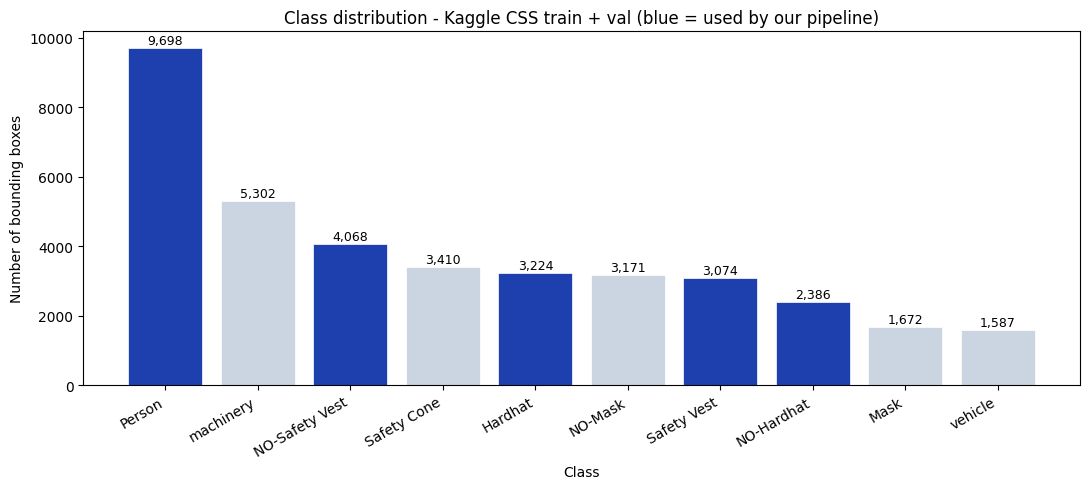

In [11]:
# =============================================================================
# Chapter 5.4 - Class distribution (Kaggle CSS train + val)
# =============================================================================
# The classes relevant to our PPE compliance pipeline are highlighted in blue.
# Other classes (Mask, Safety Cone, vehicle, machinery) are present in the raw
# data but not used by our model.

PROJECT_CLASSES = {"Person", "Hardhat", "Safety Vest", "NO-Hardhat", "NO-Safety Vest"}
class_counts = eda_df["class_name"].value_counts()

colors = [
    "#1e40af" if c in PROJECT_CLASSES else "#cbd5e1"
    for c in class_counts.index
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=colors,
              edgecolor="white", linewidth=0.5)

# Annotate each bar with its count
for bar, cnt in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{cnt:,}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Class")
ax.set_ylabel("Number of bounding boxes")
ax.set_title("Class distribution - Kaggle CSS train + val "
             "(blue = used by our pipeline)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<p style="text-align: justify;">
The chart reveals two characteristics of the data that will directly shape the training pipeline:
</p>

<ul>
  <li><strong>Person is by far the dominant class</strong> (about 26% of all bboxes). This is good news for Stage 1 &mdash; the detector will see ~9,700 worker examples to learn from.</li>
  <li><strong>Roughly 40% of the bboxes belong to classes we will not use</strong> (Mask, Safety Cone, machinery, vehicle, NO-Mask). These will be filtered out in Chapter 7 when we build a Person-only label set for YOLO &mdash; what remains is a cleaner signal for the model.</li>
  <li><strong>The PPE classes are unbalanced and asymmetric.</strong> Hardhat (3,224) outnumbers NO-Hardhat (2,386), but Safety Vest (3,074) is outnumbered by NO-Safety Vest (4,068) &mdash; meaning the dataset shows more workers wearing helmets than not, but more workers <em>without</em> vests than with them. Stage 2 will need class-aware training (class weights or balanced sampling) to avoid biasing toward the majority decision.</li>
</ul>

</div>

Bboxes per image - min : 1
                  - p25 : 8
                  - median: 11
                  - p75 : 17
                  - max : 87
                  - mean: 13.91


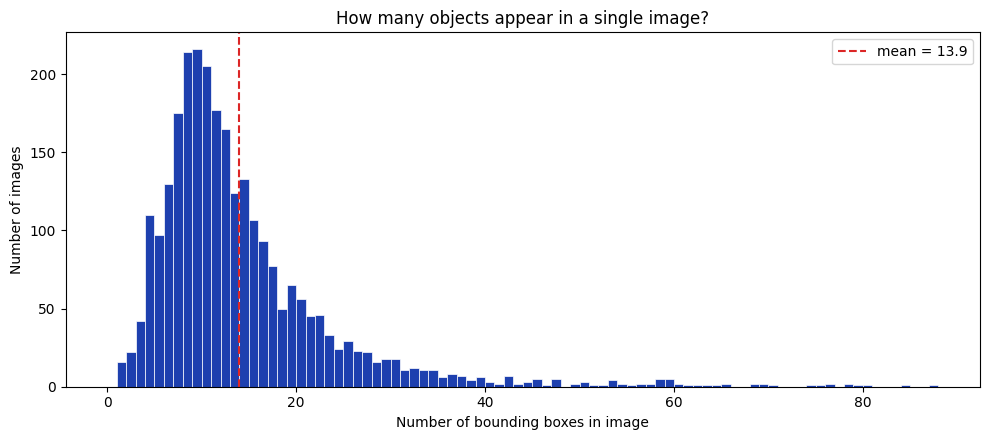

In [12]:
# =============================================================================
# Chapter 5.5 - Distribution of bounding boxes per image
# =============================================================================
bboxes_per_image = eda_df.groupby("image").size()

print(f"Bboxes per image - min : {bboxes_per_image.min()}")
print(f"                  - p25 : {bboxes_per_image.quantile(0.25):.0f}")
print(f"                  - median: {bboxes_per_image.median():.0f}")
print(f"                  - p75 : {bboxes_per_image.quantile(0.75):.0f}")
print(f"                  - max : {bboxes_per_image.max()}")
print(f"                  - mean: {bboxes_per_image.mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 4.5))
bins = range(0, int(bboxes_per_image.max()) + 2)
ax.hist(bboxes_per_image, bins=bins, color="#1e40af", edgecolor="white", linewidth=0.5)
ax.axvline(bboxes_per_image.mean(), color="#dc2626", linestyle="--",
           linewidth=1.5, label=f"mean = {bboxes_per_image.mean():.1f}")
ax.set_xlabel("Number of bounding boxes in image")
ax.set_ylabel("Number of images")
ax.set_title("How many objects appear in a single image?")
ax.legend()
plt.tight_layout()
plt.show()


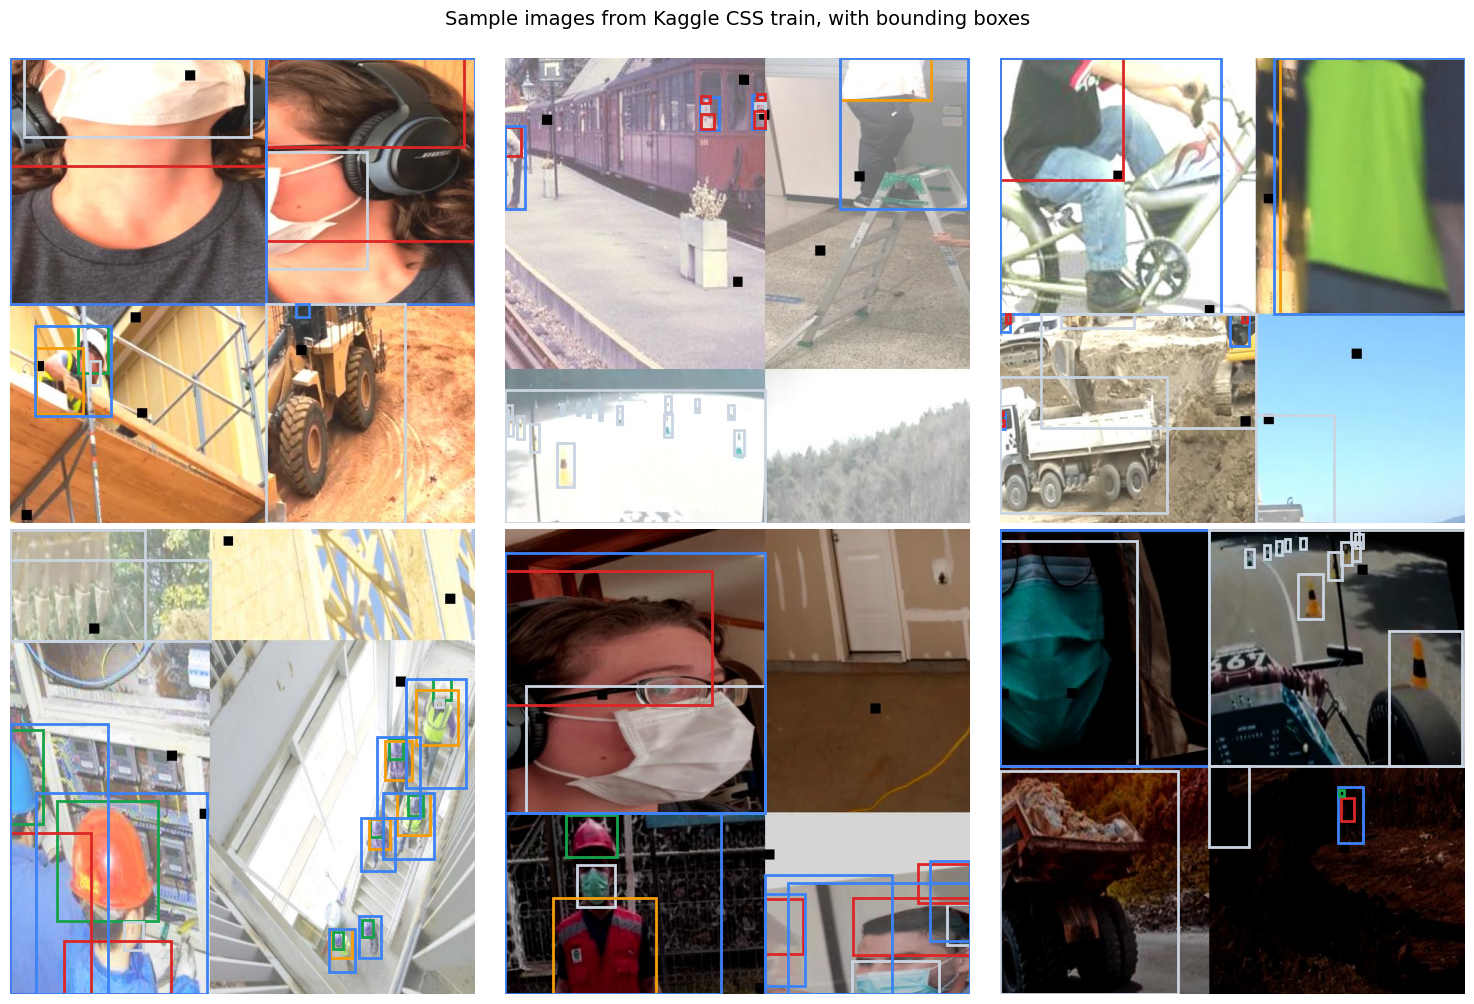

In [13]:
# =============================================================================
# Chapter 5.6 - Sample images with bounding boxes overlaid
# =============================================================================
# Colour code: only classes relevant to our pipeline are drawn in colour;
# others (Mask, Safety Cone, ...) are drawn in grey for context.

CLASS_COLORS = {
    "Person":         "#3b82f6",
    "Hardhat":        "#16a34a",
    "Safety Vest":    "#f59e0b",
    "NO-Hardhat":     "#dc2626",
    "NO-Safety Vest": "#dc2626",
}
DEFAULT_COLOR = "#cbd5e1"


def find_image_file(images_dir: Path, stem: str) -> Path | None:
    for ext in (".jpg", ".jpeg", ".png"):
        candidate = images_dir / (stem + ext)
        if candidate.exists():
            return candidate
    return None


def draw_image_with_bboxes(ax, image_path: Path, bboxes: pd.DataFrame):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    for _, row in bboxes.iterrows():
        x = (row["cx"] - row["w"] / 2) * W
        y = (row["cy"] - row["h"] / 2) * H
        w = row["w"] * W
        h = row["h"] * H
        color = CLASS_COLORS.get(row["class_name"], DEFAULT_COLOR)
        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
    ax.axis("off")


# Pick 6 random images from train, seeded for reproducibility
sample_images = (
    train_df["image"]
    .drop_duplicates()
    .sample(n=6, random_state=SEED)
    .tolist()
)
train_images_dir = CSS_DATA / "train" / "images"

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_name in zip(axes.flat, sample_images):
    img_file = find_image_file(train_images_dir, img_name)
    if img_file is None:
        ax.text(0.5, 0.5, f"Image file missing\n{img_name[:30]}...",
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue
    img_bboxes = train_df[train_df["image"] == img_name]
    draw_image_with_bboxes(ax, img_file, img_bboxes)

plt.suptitle("Sample images from Kaggle CSS train, with bounding boxes",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h3 style="color: #1e40af; margin-top: 18px;">5.7 EDA summary &mdash; key takeaways</h3>

<p style="text-align: justify;">
The Kaggle CSS train+val data contains <strong>2,719 images</strong> (2,605 train + 114 val), of which <strong>16 are "background" images with empty label files</strong> (no objects annotated). These will still be useful at training time as negative examples for Stage 1.
</p>

<p style="text-align: justify;">
Across all the data, there are <strong>37,592 bounding boxes</strong>, with an average of about <strong>14 objects per image</strong> (median 11, max 87) &mdash; the scenes are dense and will be a real challenge for the detector.
</p>

<p style="text-align: justify;">
Of the ten classes present, our pipeline uses five (Person, Hardhat, Safety Vest, NO-Hardhat, NO-Safety Vest); the other five (Mask, Safety Cone, machinery, vehicle, NO-Mask) make up about 40% of the bboxes and will be filtered out in Chapter 7.
</p>

<p style="text-align: justify;">
Among the PPE-related classes, the dataset is asymmetric: workers are more often shown <em>with</em> a helmet than without, but more often <em>without</em> a vest than with one. This asymmetry will drive design choices in Stage 2 &mdash; class weights, balanced sampling, and aggressive augmentation &mdash; to avoid a model that simply learns to predict the majority answer.
</p>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.65;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">6. Deduplication &amp; leakage check</h2>

<p style="text-align: justify;">
As part of preparing the data, a perceptual-hash (pHash) deduplication check was run on all 4,217 images
across both datasets, in every train/val/test combination. The check identified <strong>4 duplicate images</strong>
between the two datasets' test sets, which were removed &mdash; leaving <strong>4,213 images</strong> in total.
The verification script lives at <code>src/utils/deduplicate.py</code> and can be re-run at any time.
</p>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">7. Data preparation for Stage 1</h2>

<p style="text-align: justify;">
Stage 1 is a single-class person detector, so the multi-class label files of both datasets need to be filtered:
keep only the <strong>Person</strong> bounding boxes, drop everything else, and rewrite the class id to <code>0</code> (since the YOLO model will see only one class).
The filtered data is written to a new directory tree under <code>DATA_ROOT/processed_stage1/</code>,
together with a <code>data.yaml</code> file that points YOLOv8 at the train/val/test splits we defined in Chapter&nbsp;4.
</p>

<p style="text-align: justify; font-size: 13px; color: #475569;">
Note on class ids: in the source data, Person is class <code>5</code> in Kaggle CSS and class <code>6</code> in Ultralytics. After filtering both become class <code>0</code> in the processed labels.
</p>

</div>

In [ ]:
# =============================================================================
# Chapter 7.2 - Configuration and the filter-and-link helper
# =============================================================================
import shutil

# Class id of "Person" in each source dataset
KAGGLE_PERSON_CLASS      = 5
ULTRALYTICS_PERSON_CLASS = 6

# Source-data roots (defined here so chapter 7 is independent of chapter 5)
CSS_DATA       = KAGGLE_DIR / "css-data"
PROCESSED_ROOT = DATA_ROOT / "processed_stage1"


def link_or_copy(src: Path, dst: Path) -> None:
    """Hard-link the file if possible (fast, no extra disk), otherwise copy."""
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except (OSError, NotImplementedError):
        shutil.copy2(src, dst)


def filter_split(
    src_images_dir: Path,
    src_labels_dir: Path,
    dst_dir: Path,
    person_class_id: int,
) -> dict:
    """Filter one split: keep only Person bboxes, link images, write labels.

    Returns a small dict of counts for reporting.
    """
    dst_images = dst_dir / "images"
    dst_labels = dst_dir / "labels"
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    n_images = 0
    n_person_bboxes = 0
    n_empty_after_filter = 0
    n_total_labels = 0
    n_orphan_labels = 0  # labels without a matching image

    for src_label in sorted(src_labels_dir.glob("*.txt")):
        n_total_labels += 1

        # Locate matching image first; skip if none found (orphan label)
        src_img = None
        for ext in (".jpg", ".jpeg", ".png"):
            candidate = src_images_dir / (src_label.stem + ext)
            if candidate.exists():
                src_img = candidate
                break
        if src_img is None:
            n_orphan_labels += 1
            continue

        with open(src_label) as f:
            lines = f.readlines()

        person_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5 and int(parts[0]) == person_class_id:
                # Rewrite class id to 0 (single-class detector)
                person_lines.append(f"0 {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")

        dst_label = dst_labels / src_label.name
        with open(dst_label, "w") as f:
            f.writelines(person_lines)

        link_or_copy(src_img, dst_images / src_img.name)
        n_images += 1

        n_person_bboxes += len(person_lines)
        if not person_lines:
            n_empty_after_filter += 1

    return {
        "label_files":   n_total_labels,
        "images":        n_images,
        "person_bboxes": n_person_bboxes,
        "empty_labels":  n_empty_after_filter,
        "orphan_labels": n_orphan_labels,
    }


print(f"PROCESSED_ROOT = {PROCESSED_ROOT}")


In [ ]:
# =============================================================================
# Chapter 7.3 - Run the filter on all four splits
# =============================================================================
# Splits, source directories, and the source dataset's "Person" class id.
SPLITS = [
    ("train",              CSS_DATA / "train" / "images",      CSS_DATA / "train" / "labels",      KAGGLE_PERSON_CLASS),
    ("val",                CSS_DATA / "valid" / "images",      CSS_DATA / "valid" / "labels",      KAGGLE_PERSON_CLASS),
    ("test_in_domain",     CSS_DATA / "test"  / "images",      CSS_DATA / "test"  / "labels",      KAGGLE_PERSON_CLASS),
    ("test_out_of_domain", ULTRALYTICS_DIR / "images" / "train", ULTRALYTICS_DIR / "labels" / "train", ULTRALYTICS_PERSON_CLASS),
]

# For Ultralytics out-of-domain test we want ALL of Ultralytics (train+val+test),
# since we never train on it. Extend the list with its other two folders.
EXTRA_OUT_OF_DOMAIN = [
    (ULTRALYTICS_DIR / "images" / "val",  ULTRALYTICS_DIR / "labels" / "val"),
    (ULTRALYTICS_DIR / "images" / "test", ULTRALYTICS_DIR / "labels" / "test"),
]

print(f"Writing processed dataset to: {PROCESSED_ROOT}")

# Start clean so re-runs do not leave stale files behind.
if PROCESSED_ROOT.exists():
    shutil.rmtree(PROCESSED_ROOT)
print(f"  (cleared previous contents)\n")

results = {}
for split_name, src_imgs, src_lbls, person_cls in SPLITS:
    dst_dir = PROCESSED_ROOT / split_name
    counts = filter_split(src_imgs, src_lbls, dst_dir, person_cls)
    results[split_name] = counts

# Extend test_out_of_domain with the rest of Ultralytics
for src_imgs, src_lbls in EXTRA_OUT_OF_DOMAIN:
    extra = filter_split(src_imgs, src_lbls,
                         PROCESSED_ROOT / "test_out_of_domain",
                         ULTRALYTICS_PERSON_CLASS)
    for k, v in extra.items():
        results["test_out_of_domain"][k] += v

# Report
print(f"{'Split':<22s} {'images':>8s} {'Person bboxes':>14s} {'empty labels':>14s} {'orphan labels':>14s}")
print("-" * 76)
for name, c in results.items():
    print(f"{name:<22s} {c['images']:>8,} {c['person_bboxes']:>14,} {c['empty_labels']:>14,} {c['orphan_labels']:>14,}")

print("\nNotes:")
print("  - 'empty labels' = images with no Person bbox (will serve as YOLO negatives).")
print("  - 'orphan labels' = label files without a matching image (skipped).")


In [ ]:
# =============================================================================
# Chapter 7.4 - Write data.yaml for YOLOv8 and verify the result
# =============================================================================
yaml_text = (
    f"# YOLOv8 dataset definition - Stage 1 (Person detection, single class)\n"
    f"# Generated by notebooks/01_main_pipeline.ipynb, chapter 7.\n"
    f"path: {PROCESSED_ROOT.as_posix()}\n"
    f"train: train/images\n"
    f"val: val/images\n"
    f"test: test_in_domain/images   # in-domain test (Kaggle CSS test)\n"
    f"\n"
    f"# Out-of-domain test set (entire Ultralytics dataset) is evaluated separately\n"
    f"# in chapter 9 by overriding the 'val' path to test_out_of_domain/images.\n"
    f"\n"
    f"nc: 1\n"
    f"names: ['Person']\n"
)
yaml_path = PROCESSED_ROOT / "data.yaml"
yaml_path.write_text(yaml_text)

print(f"Wrote: {yaml_path}\n")
print(yaml_text)

# Quick verification: image count vs label count must match in every split
print("Verification (images vs labels match):")
for split_name in ("train", "val", "test_in_domain", "test_out_of_domain"):
    split_dir = PROCESSED_ROOT / split_name
    n_imgs = sum(1 for _ in (split_dir / "images").glob("*"))
    n_lbls = sum(1 for _ in (split_dir / "labels").glob("*.txt"))
    status = "OK" if n_imgs == n_lbls else "MISMATCH"
    print(f"  {split_name:<22s} images={n_imgs:>5,}  labels={n_lbls:>5,}  [{status}]")


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h3 style="color: #1e40af; margin-top: 18px;">7.5 What was produced</h3>

<p style="text-align: justify;">
A processed dataset tree has been written to <code>DATA_ROOT/processed_stage1/</code>:
the four splits (<em>train</em>, <em>val</em>, <em>test_in_domain</em>, <em>test_out_of_domain</em>),
each containing an <code>images/</code> folder and a <code>labels/</code> folder, with Person as the single class
(remapped to id <code>0</code>). The accompanying <code>data.yaml</code> is what we will hand to YOLOv8 in Chapter&nbsp;8.
Images are hard-linked from the original datasets whenever possible, so no extra disk space is consumed.
</p>

</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #1e3a8a; border-bottom: 2px solid #cbd5e1; padding-bottom: 4px;">8. Stage 1 &mdash; YOLOv8 training for person detection</h2>

<p style="text-align: justify;">
This chapter fine-tunes <strong>YOLOv8n</strong> on the processed dataset from Chapter&nbsp;7 to detect people in
construction-site images. Training runs for 50 epochs on the <em>train</em> split, with the <em>val</em>
split used for early-stopping and best-checkpoint selection. The trained model is saved to
<code>results/stage1/yolov8n_50e/weights/best.pt</code> and will be used in
Chapter&nbsp;9 for evaluation and in Chapter&nbsp;10 to crop workers from images for Stage&nbsp;2.
</p>

<p style="text-align: justify; font-size: 13px; color: #475569;">
The training cell takes roughly 30&ndash;90 minutes on a workstation GPU (and many hours on CPU).
To allow re-running the notebook without re-training, the cell checks for existing weights at the target path
and loads them if present &mdash; controlled by the <code>SKIP_IF_TRAINED</code> flag.
</p>

</div>

In [ ]:
# =============================================================================
# Chapter 8.2 - Stage 1 training configuration
# =============================================================================
from ultralytics import YOLO

DATA_YAML       = PROCESSED_ROOT / "data.yaml"
STAGE1_DIR      = RESULTS_DIR / "stage1"
RUN_NAME        = "yolov8n_50e"
MODEL_VARIANT   = "yolov8n.pt"     # pretrained on COCO
EPOCHS          = 50
IMGSZ           = 640
BATCH           = -1               # -1 = auto (Ultralytics picks per GPU memory)
WORKERS         = 0                # 0 avoids Windows DataLoader multiprocessing issues

# Re-running the notebook should not re-train when weights already exist.
SKIP_IF_TRAINED = True
trained_weights = STAGE1_DIR / RUN_NAME / "weights" / "best.pt"

print("Stage 1 training plan")
print(f"  Model            : {MODEL_VARIANT}")
print(f"  Epochs           : {EPOCHS}")
print(f"  Image size       : {IMGSZ}")
print(f"  Batch            : {'auto' if BATCH == -1 else BATCH}")
print(f"  Data YAML        : {DATA_YAML}")
print(f"  Output directory : {STAGE1_DIR / RUN_NAME}")
print(f"  DataLoader workers: {WORKERS}")
print(f"  Skip if trained  : {SKIP_IF_TRAINED}")
print(f"  Existing weights : {'YES (will be loaded)' if trained_weights.exists() else 'no (will train)'}")


In [ ]:
# =============================================================================
# Chapter 8.3 - Train (or load existing weights)
# =============================================================================
if SKIP_IF_TRAINED and trained_weights.exists():
    print(f"Skipping training, loading existing weights:")
    print(f"  {trained_weights}")
    model = YOLO(str(trained_weights))
    train_results = None
else:
    print(f"Starting training - this may take 30-90 minutes on a GPU.")
    print()
    model = YOLO(MODEL_VARIANT)
    train_results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        project=str(STAGE1_DIR),
        name=RUN_NAME,
        exist_ok=True,
        seed=SEED,
    )
    print()
    print(f"Training complete. Best weights saved to:")
    print(f"  {trained_weights}")


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6;">

<h3 style="color: #1e40af; margin-top: 18px;">8.4 Training complete</h3>

<p style="text-align: justify;">
The trained YOLO model is now available as <code>model</code> in memory. Its best weights are persisted to
<code>STAGE1_DIR / RUN_NAME / "weights" / "best.pt"</code> and will be used in Chapter&nbsp;9 for
quantitative evaluation (mAP, precision, recall) and in Chapter&nbsp;10 to crop workers from images for the
Stage&nbsp;2 multi-label classifier.
</p>

</div>